<a href="https://colab.research.google.com/github/2873991-Manthena/Dissertation/blob/main/DistillBert_Combined_Preprocessed_dataset_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q \
torch==2.7.1 \
torchvision==0.22.1 \
transformers==4.53.2 \
datasets==3.6.0 \
accelerate==1.8.1 \
evaluate==0.4.5

In [ ]:
###############################################################
# SECTION 1 - MOUNT GOOGLE DRIVE
###############################################################

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
###############################################################
# SECTION 2 - IMPORT LIBRARIES
###############################################################

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
###############################################################
# SECTION 3 - DATASET PATH
###############################################################

DATASET_PATH = "/content/drive/MyDrive/Datasets/"

In [ ]:
###############################################################
# SECTION 4 - LOAD COMBINED DATASET
###############################################################

df = pd.read_csv(DATASET_PATH + "combined_mbti_preprocessed.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (114741, 3)


,type,clean_text,label
0,ENTP,possibly ironic word mug also mug existence li...,3.0
1,INFP,aww man you poor poor guy I say I infp friend ...,NaN
2,ENTP,offer date marion heroic maid marion prioritiz...,3.0
3,INTP,resus may vary simple way expose large branch ...,11.0
4,INTJ,anything interest context whether contrast soc...,10.0


In [ ]:
###############################################################
# SECTION 5 - DATA PREPARATION
###############################################################

df = df[["type", "clean_text"]]

df.dropna(inplace=True)

df["clean_text"] = df["clean_text"].astype(str)

print(df.info())

display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114741 entries, 0 to 114740
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   type        114741 non-null  object
 1   clean_text  114741 non-null  object
dtypes: object(2)
memory usage: 1.8+ MB
None


,type,clean_text
0,ENTP,possibly ironic word mug also mug existence li...
1,INFP,aww man you poor poor guy I say I infp friend ...
2,ENTP,offer date marion heroic maid marion prioritiz...
3,INTP,resus may vary simple way expose large branch ...
4,INTJ,anything interest context whether contrast soc...


In [ ]:
###############################################################
# SECTION 6 - LABEL ENCODING
###############################################################

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["type"])

print("Number of Classes:", len(label_encoder.classes_))

print(label_encoder.classes_)

Number of Classes: 16
['ENFJ' 'ENFP' 'ENTJ' 'ENTP' 'ESFJ' 'ESFP' 'ESTJ' 'ESTP' 'INFJ' 'INFP'
 'INTJ' 'INTP' 'ISFJ' 'ISFP' 'ISTJ' 'ISTP']


In [ ]:
###############################################################
# SECTION 7 - TRAIN TEST SPLIT
###############################################################

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training Shape :", train_df.shape)

print("Testing Shape :", test_df.shape)

Training Shape : (91792, 3)
Testing Shape : (22949, 3)


In [ ]:
###############################################################
# SECTION 8 - LOAD DISTILBERT TOKENIZER
###############################################################

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer Loaded Successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer Loaded Successfully!


In [ ]:
###############################################################
# SECTION 9 - CREATE HUGGING FACE DATASETS
###############################################################

train_dataset = Dataset.from_pandas(
    train_df[["clean_text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["clean_text", "label"]],
    preserve_index=False
)

print(train_dataset)

print(test_dataset)

Dataset({
    features: ['clean_text', 'label'],
    num_rows: 91792
})
Dataset({
    features: ['clean_text', 'label'],
    num_rows: 22949
})


In [ ]:
###############################################################
# SECTION 10 - TOKENIZATION
###############################################################

def tokenize(batch):

    return tokenizer(
        batch["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)

test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/91792 [00:00<?, ? examples/s]

Map:   0%|          | 0/22949 [00:00<?, ? examples/s]

In [ ]:
###############################################################
# SECTION 11 - FORMAT DATASET
###############################################################

train_dataset = train_dataset.remove_columns(["clean_text"])
test_dataset = test_dataset.remove_columns(["clean_text"])

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

print("Datasets formatted successfully!")

Datasets formatted successfully!


In [ ]:
###############################################################
# SECTION 12 - LOAD DISTILBERT MODEL
###############################################################

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_encoder.classes_)
)

print("Model Loaded Successfully!")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Loaded Successfully!


In [ ]:
###############################################################
# SECTION 13 - COMPUTE METRICS
###############################################################

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
###############################################################
# SECTION 14 - TRAINING ARGUMENTS
###############################################################

training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    report_to="none"
)

In [ ]:
###############################################################
# SECTION 15 - CREATE TRAINER
###############################################################

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

print("Trainer Created Successfully!")

Trainer Created Successfully!


In [ ]:
###############################################################
# SECTION 16 - TRAIN MODEL
###############################################################

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.044100,1.010193,0.677241,0.681196,0.677241,0.674387
2,0.924400,0.949416,0.696414,0.696070,0.696414,0.694059
3,0.796400,0.973852,0.695978,0.701345,0.695978,0.695094
4,0.628800,1.011297,0.697590,0.698560,0.697590,0.696776
5,0.498100,1.058683,0.698157,0.697413,0.698157,0.697233


TrainOutput(global_step=28685, training_loss=0.8140123268567624, metrics={'train_runtime': 12315.572, 'train_samples_per_second': 37.267, 'train_steps_per_second': 2.329, 'total_flos': 3.040620827049984e+16, 'train_loss': 0.8140123268567624, 'epoch': 5.0})

In [ ]:
###############################################################
# SECTION 17 - FINAL EVALUATION
###############################################################

results = trainer.evaluate()

print("\n===== FINAL EVALUATION =====")

for key, value in results.items():
    print(f"{key}: {value}")

In [ ]:
###############################################################
# SECTION 18 - PREDICTIONS
###############################################################

predictions = trainer.predict(test_dataset)

predicted_labels = predictions.predictions.argmax(axis=1)

true_labels = predictions.label_ids

print("Prediction Completed!")

Prediction Completed!


In [ ]:
###############################################################
# SECTION 19 - CLASSIFICATION REPORT
###############################################################

from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=label_encoder.classes_,
    digits=4
))

              precision    recall  f1-score   support

        ENFJ     0.6200    0.5391    0.5767       345
        ENFP     0.6570    0.6484    0.6527      1368
        ENTJ     0.7058    0.6138    0.6566       637
        ENTP     0.6848    0.6503    0.6671      2482
        ESFJ     0.3333    0.2889    0.3095        45
        ESFP     0.4423    0.2805    0.3433        82
        ESTJ     0.7500    0.6923    0.7200       104
        ESTP     0.8633    0.7759    0.8173       415
        INFJ     0.6996    0.7107    0.7051      3287
        INFP     0.6599    0.7057    0.6820      2793
        INTJ     0.7203    0.7385    0.7293      4704
        INTP     0.7348    0.7441    0.7394      5253
        ISFJ     0.5946    0.5399    0.5659       163
        ISFP     0.4909    0.4716    0.4811       229
        ISTJ     0.5676    0.4345    0.4922       290
        ISTP     0.6528    0.6676    0.6601       752

    accuracy                         0.6982     22949
   macro avg     0.6361   

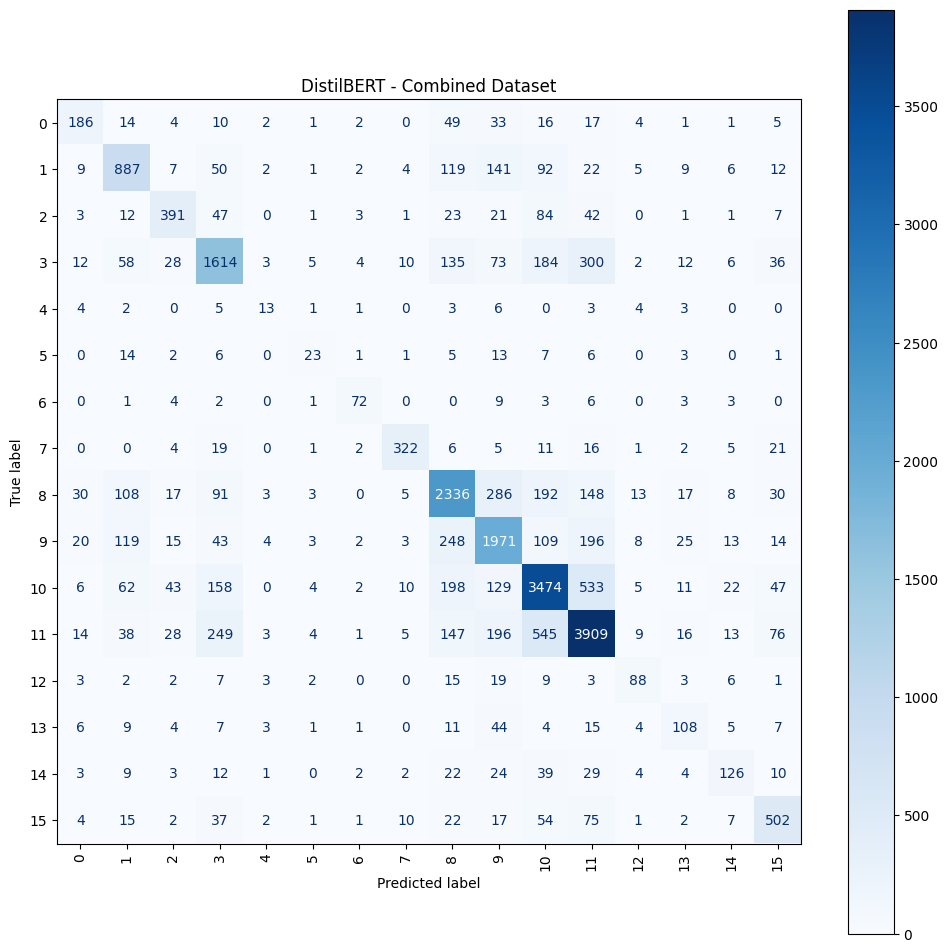

In [ ]:
###############################################################
# SECTION 20 - CONFUSION MATRIX
###############################################################

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12,12))

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted_labels,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

plt.title("DistilBERT - Combined Dataset")

plt.show()

In [ ]:
###############################################################
# DIAGNOSTIC - RAW MBTI1 DISTILBERT
###############################################################

print("===== DATA =====")
print("Dataset shape:", df.shape)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\n===== LABELS =====")
print("Number of classes:", len(label_encoder.classes_))
print("Classes:", label_encoder.classes_)

print("\n===== MODEL =====")
print("Number of model labels:", model.config.num_labels)

print("\n===== TRUE LABEL DISTRIBUTION =====")
print(pd.Series(y_true).value_counts().sort_index())

print("\n===== PREDICTED LABEL DISTRIBUTION =====")
print(pd.Series(y_pred).value_counts().sort_index())

print("\n===== LABEL MAPPING =====")
for i, label in enumerate(label_encoder.classes_):
    print(i, "->", label)